In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

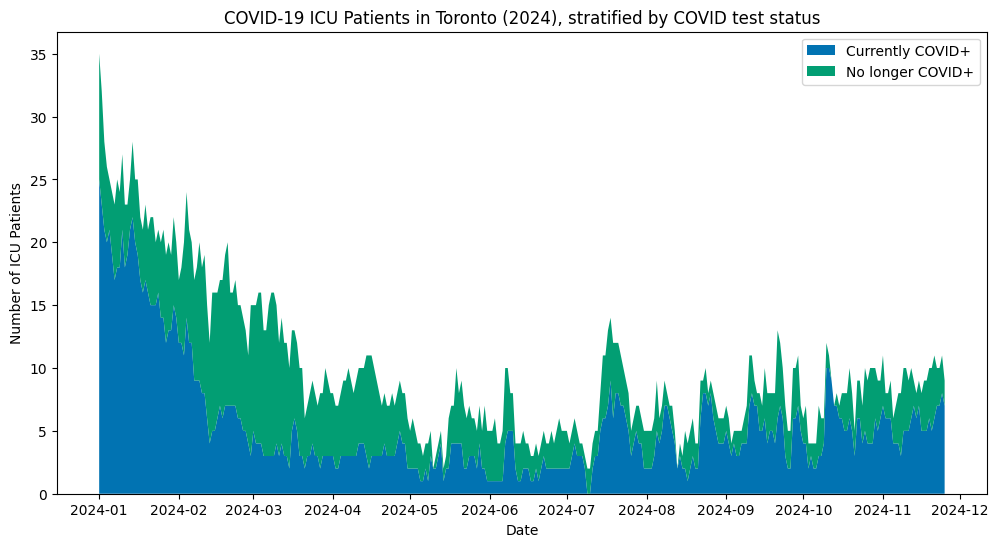

In [ ]:
#Link to the dataset: https://data.ontario.ca/dataset/covid-19-cases-in-hospital-and-icu-by-ontario-health-region/resource/e760480e-1f95-4634-a923-98161cfb02fa

#Read the datafile
data = pd.read_csv("/Users/batukaya/DSI/visualization/02_activities/assignments/Assignment-3/region_hospital_icu_covid_data.csv")
#Drop rows with missing values
data = data.dropna()
#Ensure data type is numeric
data['icu_current_covid'] = pd.to_numeric(data['icu_current_covid'], errors='coerce')
data['icu_former_covid'] = pd.to_numeric(data['icu_former_covid'], errors='coerce')
#Create df with data from 2024
data['date'] = pd.to_datetime(data['date'])
data_2024 = data[data['date'].dt.year == 2024]

#Only look at the trends in Toronto
region = 'TORONTO'
df = data_2024[data_2024['oh_region'] == region]

#Create the plot
plt.figure(figsize=(12,6))

palette = sns.color_palette('colorblind6',2)

plt.stackplot(
    df['date'],
    df['icu_current_covid'],
    df['icu_former_covid'],
    labels = ['Currently COVID+', 'No longer COVID+'],
    colors=palette
)
plt.title('COVID-19 ICU Patients in Toronto (2024), stratified by COVID test status')
plt.xlabel('Date')
plt.ylabel('Number of ICU Patients')
plt.legend(loc='upper right')